## Step-by-step instructions to interact HEST-1k 

This tutorial will guide you to:

- Read HEST data
- Visualized the spots over a downscaled version of the WSI
- Saving HESTData into Pyramidal Tif and anndata


This tutorial assumes that the user has already downloaded HEST-1k (in its entirety or partially). 

### Read HEST

In [3]:
from hest import iter_hest

downloaded_ids = ['TENX95', 'TENX99']

# Iterate through a subset of hest
for st in iter_hest('../hest_data', id_list=downloaded_ids, load_transcripts=True):

    # ST (adata):
    adata = st.adata
    print('\n* Scanpy adata:')
    print(adata)

    # WSI:
    wsi = st.wsi
    print('\n* WSI:')
    print(wsi)
    
    # Shapes:
    shapes = st.shapes
    print('\n* Shapes:')
    print(shapes)
    
    # Tissue segmentation
    tissue_contours = st.tissue_contours
    print('\n* Tissue contours:')
    print(tissue_contours)
    
    # Conversion to SpatialData
    sdata = st.to_spatial_data()
    print('\n* SpatialData conversion:')
    print(sdata)


/Users/felipecolombelli/phd/HEST/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_qc.py:432: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]



* Scanpy adata:
AnnData object with n_obs × n_vars = 11845 × 541
    obs: 'in_tissue', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'array_col', 'array_row', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'

* WSI:
<width=48376, height=53738, backend=OpenSlideWSI>

* Shapes:
[name: cellvit, coord-system: he, <not loaded>, name: xenium_cell, coord-system: he, <not loaded>, name: xenium_nucleus, coord-system: he, <not loaded>]

* Tissue contours:
  tissue_id                                           geometry
0         0  POLYGON ((14052 2848, 14025 2874, 13998 2874, ...

* SpatialData conversio

In [12]:
st.adata

AnnData object with n_obs × n_vars = 23060 × 541
    obs: 'in_tissue', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'array_col', 'array_row', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito'
    uns: 'spatial'
    obsm: 'spatial'

In [13]:
len(st.transcript_df.cell_id.unique())

890373

`st.adata` is a spatial scanpy object containing the following:
## Observations (st.adata.obs)
- `in_tissue`: Indicator if the observation is within the tissue (`in_tissue` comes from the initial Visium/Xenium run and might not be accurate, prefer the segmentation obtained by st.segment_tissue() instead).
- `pxl_col_in_fullres`: Pixel column position of the patch/spot centroid in the full resolution image.
- `pxl_row_in_fullres`: Pixel row position of the patch/spot centroid in the full resolution image.
- `array_col`: Patch/spot column position in the array.
- `array_row`: Patch/spot row position in the array.
- `n_counts`: Number of counts for each observation.
- `n_genes_by_counts`: Number of genes detected by counts in each observation.
- `log1p_n_genes_by_counts`: Log-transformed number of genes detected by counts.
- `total_counts`: Total counts per observation.
- `log1p_total_counts`: Log-transformed total counts.
- `pct_counts_in_top_50_genes`: Percentage of counts in the top 50 genes.
- `pct_counts_in_top_100_genes`: Percentage of counts in the top 100 genes.
- `pct_counts_in_top_200_genes`: Percentage of counts in the top 200 genes.
- `pct_counts_in_top_500_genes`: Percentage of counts in the top 500 genes.
- `total_counts_mito`: Total mitochondrial counts per observation. (note that this field might not be accurate)
- `log1p_total_counts_mito`: Log-transformed total mitochondrial counts. (note that this field might not be accurate)
- `pct_counts_mito`: Percentage of counts that are mitochondrial. (note that this field might not be accurate)

## Variables (st.adata.var)
- `n_cells_by_counts`: Number of cells detected by counts for each variable.
- `mean_counts`: Mean counts per variable.
- `log1p_mean_counts`: Log-transformed mean counts.
- `pct_dropout_by_counts`: Percentage of dropout events by counts.
- `total_counts`: Total counts per variable.
- `log1p_total_counts`: Log-transformed total counts.
- `mito`: Indicator if the gene is mitochondrial. (note that this field might not be accurate)

## Unstructured (st.adata.uns)
- `spatial`: Contains a downscaled version of the full resolution image in `st.adata.uns['spatial']['ST']['images']['downscaled_fullres']`

## Observation-wise Multidimensional (st.adata.obsm)
- `spatial`: Pixel coordinates of spots/patches centroids on the full resolution image. (first column is x axis, second column is y axis)

In [42]:
st.meta

{'pixel_size_um_embedded': 1.0,
 'run_name': 'human_breast_ffpe_large_sections',
 'run_start_time': '2022-12-02T22:21:44Z',
 'region_name': 'Xenium_V1_FFPE_Human_Breast_IDC_Big_1',
 'preservation_method': 'FFPE',
 'num_cells': 892966,
 'transcripts_per_cell': 100.0,
 'transcripts_per_100um': 58.7800155404293,
 'cassette_name': 'SIM1',
 'slide_id': '0002178',
 'panel_design_id': 'hBreast_v1',
 'panel_name': 'Xenium Human Breast GEX',
 'panel_organism': 'Human',
 'panel_tissue_type': 'Breast',
 'panel_num_targets_predesigned': 280,
 'panel_num_targets_custom': 0,
 'pixel_size': 0.2125,
 'instrument_sn': 'XETG00001',
 'instrument_sw_version': '1.0.0.3',
 'analysis_sw_version': 'xenium-1.0.2',
 'experiment_uuid': '20943ebd-2e42-4ef9-80b7-eca8802a8e57',
 'cassette_uuid': '32d45b34-7819-48a7-9746-6661de3e7dfb',
 'roi_uuid': 'af6cf642-a9ce-4082-be4a-6726311377f4',
 'z_step_size': 3.0,
 'well_uuid': 'def_d0c31c41_rec_ae1d67b7',
 'images': {'morphology_filepath': 'morphology.ome.tif',
  'morpho

In [49]:
st.adata.var.iloc[95:150]

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,mito
CCPG1,21022,25.251648,3.267729,8.837814,582303,13.274748,False
EPCAM,20217,44.216305,3.811458,12.328708,1019628,13.834949,False
SDC4,19859,19.444146,3.017697,13.881180,448382,13.013403,False
AGR3,16040,20.298395,3.058632,30.442324,468081,13.056399,False
CXCL16,20550,14.296921,2.727652,10.884649,329687,12.705902,False
FLNB,21856,98.997875,4.605149,5.221162,2282891,14.640954,False
ANKRD30A,6666,0.397528,0.334705,71.092801,9167,9.123474,False
KRT6B,6502,1.454814,0.898051,71.803990,33548,10.420762,False
C2orf42,16978,2.422507,1.230373,26.374675,55863,10.930675,False
TRAPPC3,21112,33.796444,3.549515,8.447528,779346,13.566212,False


In [45]:
st.adata.X.shape

(23060, 541)

In [7]:
st.adata.obsm['spatial'].shape

(23060, 2)

In [9]:
st.adata.obs

,in_tissue,pxl_col_in_fullres,pxl_row_in_fullres,array_col,array_row,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
000x066,True,31316.491789,263.820603,66,0,33,28,3.367296,33,3.526361,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x067,True,31787.080024,263.820603,67,0,44,31,3.465736,44,3.806662,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x068,True,32257.668259,263.820603,68,0,54,38,3.663562,54,4.007333,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x069,True,32728.256495,263.820603,69,0,57,38,3.663562,57,4.060443,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x070,True,33198.844730,263.820603,70,0,84,55,4.025352,84,4.442651,94.047619,100.0,100.0,100.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227x098,True,46375.315318,107087.350015,98,227,5,4,1.609438,5,1.791759,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x099,True,46845.903553,107087.350015,99,227,1,1,0.693147,1,0.693147,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x100,True,47316.491789,107087.350015,100,227,3,3,1.386294,3,1.386294,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x101,True,47787.080024,107087.350015,101,227,1,1,0.693147,1,0.693147,100.000000,100.0,100.0,100.0,0,0.0,0.0


In [25]:
st.adata.X.shape

(23060, 541)

In [31]:
st.adata.obs

,in_tissue,pxl_col_in_fullres,pxl_row_in_fullres,array_col,array_row,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
000x066,True,31316.491789,263.820603,66,0,33,28,3.367296,33,3.526361,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x067,True,31787.080024,263.820603,67,0,44,31,3.465736,44,3.806662,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x068,True,32257.668259,263.820603,68,0,54,38,3.663562,54,4.007333,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x069,True,32728.256495,263.820603,69,0,57,38,3.663562,57,4.060443,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x070,True,33198.844730,263.820603,70,0,84,55,4.025352,84,4.442651,94.047619,100.0,100.0,100.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227x098,True,46375.315318,107087.350015,98,227,5,4,1.609438,5,1.791759,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x099,True,46845.903553,107087.350015,99,227,1,1,0.693147,1,0.693147,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x100,True,47316.491789,107087.350015,100,227,3,3,1.386294,3,1.386294,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x101,True,47787.080024,107087.350015,101,227,1,1,0.693147,1,0.693147,100.000000,100.0,100.0,100.0,0,0.0,0.0


In [ ]:
runx1_expr = st.adata[: , ['RUNX1']].X
runx1_expr

ArrayView([[1],
           [0],
           [1],
           ...,
           [0],
           [0],
           [0]], dtype=uint16)

In [38]:
import numpy as np

np.log1p(runx1_expr)

array([[0.6931472],
       [0.       ],
       [0.6931472],
       ...,
       [0.       ],
       [0.       ],
       [0.       ]], dtype=float32)

Text(0.5, 0, 'RUNX1 expression')

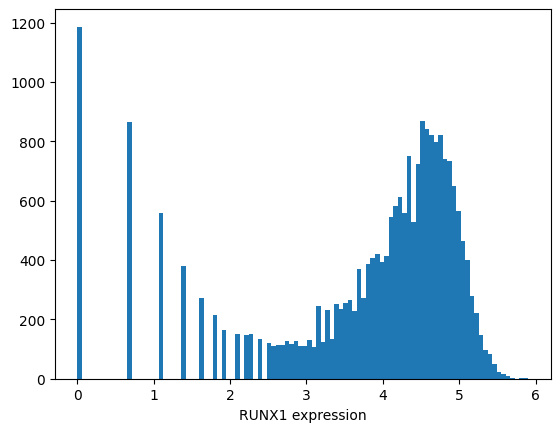

In [39]:
# plot RUNX1 histogram expression
import matplotlib.pyplot as plt

plt.hist(np.log1p(runx1_expr), bins=100)
plt.xlabel('RUNX1 expression')

In [23]:
st.adata[: , ['RUNX1']].obs

,in_tissue,pxl_col_in_fullres,pxl_row_in_fullres,array_col,array_row,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
000x066,True,31316.491789,263.820603,66,0,33,28,3.367296,33,3.526361,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x067,True,31787.080024,263.820603,67,0,44,31,3.465736,44,3.806662,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x068,True,32257.668259,263.820603,68,0,54,38,3.663562,54,4.007333,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x069,True,32728.256495,263.820603,69,0,57,38,3.663562,57,4.060443,100.000000,100.0,100.0,100.0,0,0.0,0.0
000x070,True,33198.844730,263.820603,70,0,84,55,4.025352,84,4.442651,94.047619,100.0,100.0,100.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227x098,True,46375.315318,107087.350015,98,227,5,4,1.609438,5,1.791759,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x099,True,46845.903553,107087.350015,99,227,1,1,0.693147,1,0.693147,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x100,True,47316.491789,107087.350015,100,227,3,3,1.386294,3,1.386294,100.000000,100.0,100.0,100.0,0,0.0,0.0
227x101,True,47787.080024,107087.350015,101,227,1,1,0.693147,1,0.693147,100.000000,100.0,100.0,100.0,0,0.0,0.0


In [37]:
import pandas as pd
meta_df = pd.read_csv('../assets/HEST_v1_1_0.csv')
for col, val in meta_df[meta_df["id"] == "TENX99"].iterrows():
    print(f'{col}: {val}')

153: dataset_title                 FFPE Human Breast using the Entire Sample Area
id                                                                    TENX99
image_filename                                                    TENX99.tif
organ                                                                 Breast
disease_state                                                         Cancer
oncotree_code                                                            IDC
species                                                         Homo sapiens
patient                                                            patient 1
st_technology                                                         Xenium
data_publication_date                                                1/22/23
license                                         Creative Commons Attribution
study_link                                                               NaN
download_page_link1        https://www.10xgenomics.com/datasets/ffpe-hu

## Visualizing the spots over a downscaled version of the WSI

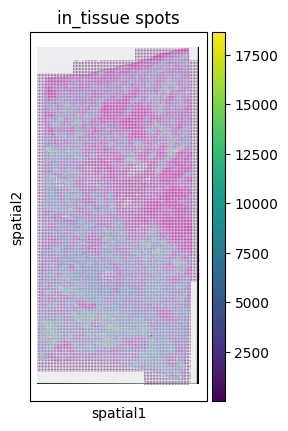

In [3]:
# visualize the spots over a downscaled version of the full resolution image
save_dir = '.'
st.save_spatial_plot(save_dir)


## Saving to pyramidal tiff and h5
Save `HESTData` object to `.tiff` + expression `.h5ad` and a metadata file.

In [ ]:
# Warning saving a large image to pyramidal tiff (>1GB) can be slow on a hard drive.
st.save(save_dir, pyramidal=True)

## Tissue segmentation

We integrated 2 tissue segmentation methods:

- Image processing-based using Otsu thresholding 
- Deep learning-based using a fine-tuned DeepLabV3 ResNet50


In [ ]:
save_dir = '.'

name = 'tissue_seg_otsu'
st.segment_tissue(method='otsu') 
st.save_tissue_seg_pkl(save_dir, name)

name = 'tissue_seg_deep'
st.segment_tissue(method='deep') 


## Changing the Patching/pooling size

### Patching
You can change the size of patches around the spots with `dump_patches`:

In [ ]:
# directory where the patch .h5 will be saved
patch_save_dir = './processed'
new_patch_size = 224


st.dump_patches(
    patch_save_dir,
    name='demo',
    target_patch_size=new_patch_size,
    target_pixel_size=0.5 # pixel size of the patches in um/px after rescaling
)

### Changing the Pooling size

You can change the pooling size of Xenium/Visium HD samples stored in `HESTData.adata` with the following:

In [ ]:
from hest.readers import pool_transcripts_xenium
from hest import iter_hest

new_spot_size = 200
new_patch_size = 224
patch_save_dir = './processed'

# Iterate through a subset of hest
for st in iter_hest('../hest_data', id_list=['TENX105'], load_transcripts=True,):
    print(st.transcript_df)

    st.adata = pool_transcripts_xenium(
                    st.transcript_df, # Feel free to convert st.transcript_df to a Dask DataFrame if you are working with limited RAM.
                    st.pixel_size, 
                    key_x='he_x',
                    key_y='he_y',
                    spot_size_um=new_spot_size
                )


    # We change the spots, so we need to re-extract the patches
    st.dump_patches(
        patch_save_dir,
        name='demo',
        target_patch_size=new_patch_size, # target patch size in 224
        target_pixel_size=0.5 # pixel size of the patches in um/px after rescaling
    )

## Batch effect visualization

In [ ]:
import pandas as pd
from hest.batch_effect import filter_hest_stromal_housekeeping, get_silhouette_score, plot_umap

meta_df = pd.read_csv('../assets/HEST_v1_1_0.csv')


meta_df = meta_df[
    (meta_df['st_technology'] == 'Visium') & 
    (meta_df['disease_state'] == 'Cancer') & 
    (meta_df['oncotree_code'] == 'IDC') & 
    (meta_df['species'] == 'Homo sapiens')
]

# We filter spots, such that:
# - we only keep the most stable housekeeping genes (based on https://housekeeping.unicamp.br/?download)
# - we only keep the spots under the stroma (based on CellViT segmentation)
adata_list = filter_hest_stromal_housekeeping(meta_df, hest_dir='../hest_data')

labels = meta_df['id'].values
score = get_silhouette_score(adata_list, labels=labels)
# (-1: strong overlap between clusters, can be indicative of a small batch effect, 1: poor overlap between clusters, can be indicative of a strong batch effect)
print(f'Silhouette score is {score}')


plot_umap(adata_list, labels, 'batch_whole_tissue.png', umap_kwargs={'min_dist': 0.6})

## Loading transcripts (for Xenium only)
The transcript dataframe contains the following columns:
- `cell_id` (default Xenium Explorer flag): id of cell containing this transcript
- `he_x`, `he_y`: x, y coordinate or transcript on the HE WSI in pixels (aligned with a non-rigid transformation)
- `feature_name`: name of transcript
- `qv` (default Xenium Explorer flag): Phred-scaled quality value (Q-Score) estimating the probability of incorrect call

In [ ]:
from hest import iter_hest

# Iterate through a subset of hest
for st in iter_hest('../hest_data', id_list=['TENX105'], load_transcripts=True):
    print(st.transcript_df)

In [17]:
st.transcript_df

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,x_location_pxl,y_location_pxl,dapi_x,dapi_y,he_x,he_y
0,281474976710656,-1,0,b'RUNX1',7352.790039,22577.537109,21.059465,40.000000,34601.363281,106247.234375,34601.363281,106247.234375,34601.363281,106247.234375
1,281474976710657,-1,0,b'ITGAX',7398.895508,22373.404297,21.242352,12.577451,34818.332031,105286.609375,34818.332031,105286.609375,34818.332031,105286.609375
2,281474976710658,-1,0,b'TCIM',7400.779785,22289.593750,21.097544,40.000000,34827.199219,104892.203125,34827.199219,104892.203125,34827.199219,104892.203125
3,281474976710659,-1,0,b'TCIM',7434.090820,22711.781250,20.876198,11.656452,34983.957031,106878.968750,34983.957031,106878.968750,34983.957031,106878.968750
4,281474976710660,-1,0,b'LUM',7434.583496,22193.472656,21.033558,40.000000,34986.273438,104439.867188,34986.273438,104439.867188,34986.273438,104439.867188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126857385,283274568466135,397998,0,b'HMGA1',7919.396484,21176.013672,23.295231,40.000000,37267.746094,99651.828125,37267.746094,99651.828125,37267.746094,99651.828125
126857386,283274568466137,396331,0,b'CLIC6',7920.170898,21650.021484,23.817303,40.000000,37271.390625,101882.453125,37271.390625,101882.453125,37271.390625,101882.453125
126857387,283274568466143,395088,0,b'SQLE',7920.746094,21491.496094,24.461872,40.000000,37274.097656,101136.453125,37274.097656,101136.453125,37274.097656,101136.453125
126857388,283274568466145,397996,0,b'DST',7919.966797,21188.933594,22.088409,40.000000,37270.429688,99712.625000,37270.429688,99712.625000,37270.429688,99712.625000


**Warning:** The segmentation contained in 'xenium_seg/' (accessed with st.get_shapes('xenium_cell', 'he') or st.get_shapes('xenium_nucleus', 'he')) is different than the CellViT segmentation. It was obtained by the Xenium instrument directly by segmenting the DAPI stained image, the DAPI segmented cells were then aligned to H&E with a non rigid transform.

### Linking transcripts with cells
Each transcript is associated with a cell id (derived by the Xenium analyzer directly). See column `cell_id` in the transcript dataframe.

In [19]:
transcripts = st.transcript_df
shapes = st.get_shapes('xenium_cell', 'he').shapes

cell_id = 1

# Print the transcripts associated with a particular cell
display(transcripts[transcripts['cell_id'] == cell_id])
display(shapes[shapes.index == cell_id])


,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,x_location_pxl,y_location_pxl,dapi_x,dapi_y,he_x,he_y
50983907,282325380238303,1,0,b'TCIM',835.265686,10494.474609,19.999495,9.415115,3930.661865,49385.761719,3930.661865,49385.761719,3930.661865,49385.761719
50984092,282325380238490,1,1,b'LUM',844.907104,10500.132812,18.118536,19.846424,3976.033203,49412.386719,3976.033203,49412.386719,3976.033203,49412.386719
50984113,282325380238511,1,0,b'LUM',846.087708,10497.310547,18.302881,40.000000,3981.589111,49399.105469,3981.589111,49399.105469,3981.589111,49399.105469
50984219,282325380238617,1,0,b'LUM',850.734253,10491.657227,16.064150,40.000000,4003.455078,49372.503906,4003.455078,49372.503906,4003.455078,49372.503906
50993685,282325380248285,1,1,b'PDE4A',842.657043,10497.412109,20.077856,40.000000,3965.444824,49399.585938,3965.444824,49399.585938,3965.444824,49399.585938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51451894,282325380722829,1,0,b'DNTTIP1',845.517761,10495.939453,18.430851,40.000000,3978.906982,49392.656250,3978.906982,49392.656250,3978.906982,49392.656250
51451908,282325380722843,1,0,b'ADAM9',846.683594,10499.575195,18.996464,40.000000,3984.393311,49409.765625,3984.393311,49409.765625,3984.393311,49409.765625
51463681,282325380735135,1,0,b'LUM',834.362427,10491.248047,20.409435,40.000000,3926.411377,49370.578125,3926.411377,49370.578125,3926.411377,49370.578125
51463858,282325380735317,1,0,b'TOP2A',840.549133,10490.158203,20.062920,40.000000,3955.525146,49365.449219,3955.525146,49365.449219,3955.525146,49365.449219


,geometry
1,"POLYGON ((3927 49346.004, 3918 49354, 3910 493..."
